In [1]:
%load_ext autoreload
%autoreload 2

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

from phd_project.plotting.plotting import (
    plot_conditional_spectrum, 
    apply_log_axis_format, 
    apply_grid_lines,
    plot_conditional_distribution
    )
from phd_project.config import config

cfg = config.load_config()

In [3]:
assumed_rake = -90

gcim_dist_fp = cfg["proc_data"]["gcim_dists"] / f"gcim_dist_AvgSA_03_rake{int(assumed_rake)}.pickle"

no_file = False
if gcim_dist_fp.is_file():
    with open(gcim_dist_fp, "rb") as file:
        gcim_AvgSA_03 = pickle.load(file)
    print("Existing GCIM distribution data loaded...")
else:
    no_file = True
    print("No existing GCIM distribution data found...")


Existing GCIM distribution data loaded...


(0.01, 1)

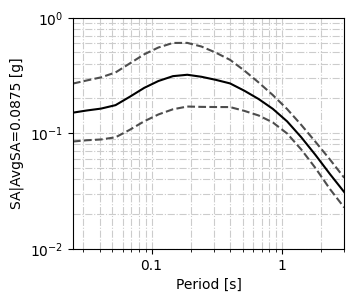

In [29]:
site = 31
poe = 0.004988
gcim_stats = gcim_AvgSA_03[(site, poe)]["stats"]

fig, ax = plt.subplots(figsize=(3.5, 3))
ax = plot_conditional_spectrum(ax, gcim_stats, take_exp=True)
ax = apply_log_axis_format(ax, "x")
apply_grid_lines(ax)
ax.set_xlabel("Period [s]")
ax.set_ylabel("SA|AvgSA=0.0875 [g]")
ax.set_xlim(0.025, 3)
ax.set_ylim(1e-2, 1)

Text(0, 0.5, 'CDF')

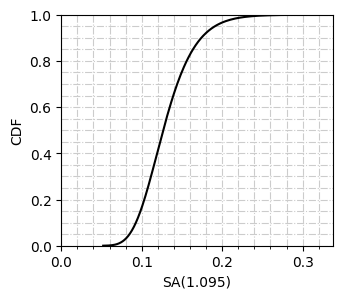

In [37]:
site = 31
poe = 0.004988
im = "SA(1.095)"
gcim_cdfs = gcim_AvgSA_03[(site, poe)]["cdfs"]

fig, ax = plt.subplots(figsize=(3.5, 3))
ax = plot_conditional_distribution(ax, gcim_cdfs[im], take_exp=False,
                                   style={"cdf": {"color":"k"}})
# ax = apply_log_axis_format(ax, "x")
apply_grid_lines(ax)
ax.set_xlabel(f"{im}")
ax.set_ylabel("CDF")
# ax.set_xlim(0.025, 3)
# ax.set_ylim(1e-2, 1)

In [27]:
gcim_cdfs.keys()

dict_keys(['RSD595', 'PGA', 'SA(0.025)', 'SA(0.032)', 'SA(0.041)', 'SA(0.053)', 'SA(0.068)', 'SA(0.088)', 'SA(0.113)', 'SA(0.146)', 'SA(0.188)', 'SA(0.241)', 'SA(0.311)', 'SA(0.4)', 'SA(0.514)', 'SA(0.662)', 'SA(0.851)', 'SA(1.095)', 'SA(1.409)', 'SA(1.812)', 'SA(2.332)', 'SA(3.0)'])

In [40]:
import re
def _get_SA_periods_SA_strings(ims: list[str]):
    # Parse Periods from column headers
    pattern = re.compile(r"SA\(([\d.]+)\)")
    periods = np.array([float(pattern.search(im).group(1)) for im in ims if im.startswith("SA")])
    return periods

(0.01, 1)

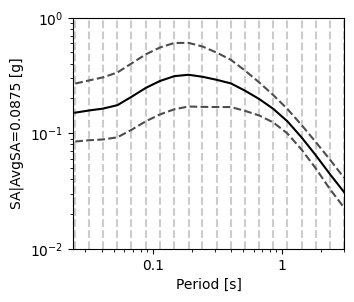

In [54]:
site = 31
poe = 0.004988
gcim_stats = gcim_AvgSA_03[(site, poe)]["stats"]

y_min = 1e-2
y_max = 1
y_lim = (y_min, y_max)

periods = _get_SA_periods_SA_strings(list(gcim_stats.index))

fig, ax = plt.subplots(figsize=(3.5, 3))

# ax = plot_conditional_spectrum(ax, gcim_stats, take_exp=True)
ax.vlines(periods, [y_min]*len(periods), [y_max]*len(periods), ls="--", color="0.8")
ax = plot_conditional_spectrum(ax, gcim_stats, take_exp=True)
ax = apply_log_axis_format(ax, "x")
# apply_grid_lines(ax)
ax.set_xlabel("Period [s]")
ax.set_ylabel("SA|AvgSA=0.0875 [g]")
ax.set_xlim(0.024, 3.01)
ax.set_ylim(*y_lim)
